# AI-ML Assignment 4 : Breast Cancer Classification using K-Nearest Neighbors (KNN)



**Objective:** Build a K-Nearest Neighbors (KNN) classification model to predict whether a
breast tumor is **Malignant (M)** or **Benign (B)** based on diagnostic measurements computed
from digitized images of breast mass cell nuclei.

**Dataset:** [Breast Cancer Wisconsin Diagnostic Dataset on Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)
(569 rows, 33 columns)

---


## Setup: Loading the Dataset




In [1]:
# Import pandas — the main library we use to load and manipulate tabular data
import pandas as pd

# This URL points to a raw CSV file on GitHub — an exact mirror of the Kaggle
# "Breast Cancer Wisconsin (Diagnostic)" dataset (569 rows, 33 columns, including the
# classic empty "Unnamed: 32" column and text-based "diagnosis" column).
url = "https://raw.githubusercontent.com/Muhd-Shahid/Breast-Cancer-Wisconsin/master/data_breast-cancer-wiscons.csv"

# pd.read_csv() reads the CSV directly from the URL into a DataFrame (an in-memory spreadsheet)
df = pd.read_csv(url)



print("Dataset loaded successfully!")
print("Shape of dataset (rows, columns):", df.shape)


Dataset loaded successfully!
Shape of dataset (rows, columns): (569, 33)


---
## Task 1: Data Understanding 

We will:
1. Load the dataset using Pandas (done above ✅)
2. Display the first five records
3. Identify numerical features and the target variable
4. Display dataset information and summary statistics


In [2]:
# .head() shows the first 5 rows — a quick sanity check that the data loaded correctly
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# .info() shows column names, non-null counts, and data types for every column
# This is the fastest way to spot the target column, numerical features, and any oddities
# (like a column that's entirely empty).
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
# .describe() gives summary statistics (mean, std, min, max, quartiles) for numerical columns
df.describe()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


### Identifying feature types and the target variable

Looking at the output above:

| Column group | Examples | Type / Role |
|---|---|---|
| `id` | `842302`, `842517`, ... | Identifier — not a real feature, carries no diagnostic information |
| `diagnosis` | `M`, `B` | **Target variable** (Malignant / Benign) |
| Measurement columns | `radius_mean`, `texture_mean`, `perimeter_mean`, `area_mean`, ... `fractal_dimension_worst` | **Numerical features** (30 in total — mean, standard-error, and "worst" versions of 10 base measurements) |
| `Unnamed: 32` | all `NaN` | An empty artifact column with no data — must be dropped |

- **Numerical features:** 30 columns describing cell nuclei characteristics (radius, texture,
  perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal
  dimension — each given as a mean, standard error, and "worst" value).
- **Target variable:** `diagnosis` (`M` = Malignant, `B` = Benign)
- `id` and `Unnamed: 32` are **not** useful features and will be removed during preprocessing.


In [5]:
# Let's confirm the class balance of our target variable — an important thing to check
# before building any classifier
print("Diagnosis value counts:")
print(df['diagnosis'].value_counts())
print("\nAs percentages:")
print((df['diagnosis'].value_counts(normalize=True) * 100).round(2), "%")


Diagnosis value counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

As percentages:
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64 %


**Observation on class balance:** About 63% of tumors are Benign and 37% are Malignant.
This is a fairly reasonable balance (not severely skewed), but we'll still look at precision,
recall, and F1-score in addition to accuracy when evaluating the model later.


---
## Task 2: Data Preprocessing 

We will:
- Check for missing values
- Remove unnecessary columns (if any)
- Encode the target variable
- Normalize/standardize the feature values
- Split the dataset into 80% training and 20% testing


In [6]:
# .isnull().sum() checks for missing (NaN) values in each column.
# We only display columns that actually HAVE missing values, to keep the output readable.
missing = df.isnull().sum()
print("Columns with missing values:")
print(missing[missing > 0])


Columns with missing values:
Unnamed: 32    569
dtype: int64


**Observation:** The `Unnamed: 32` column is **entirely empty** (569 missing values out
of 569 rows) — this is a known artifact of how the original CSV was exported (an extra trailing
comma created a phantom empty column). None of the actual diagnostic measurement columns have
any missing values. We'll drop `Unnamed: 32` in the next step rather than trying to fill it,
since it never held any real data to begin with.


In [7]:
# Remove unnecessary columns:
# - 'id' is just a unique patient identifier with no diagnostic meaning
# - 'Unnamed: 32' is a completely empty artifact column
df = df.drop(['id', 'Unnamed: 32'], axis=1)

print("Shape after removing unnecessary columns:", df.shape)
print("Remaining columns:", df.shape[1], "(1 target + 30 numerical features)")


Shape after removing unnecessary columns: (569, 31)
Remaining columns: 31 (1 target + 30 numerical features)


In [8]:
# Encode the target variable: KNN (like all scikit-learn classifiers) needs numeric labels,
# not text. We map Malignant -> 1 and Benign -> 0.
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print("Encoded diagnosis value counts:")
print(df['diagnosis'].value_counts())
print("(1 = Malignant, 0 = Benign)")


Encoded diagnosis value counts:
diagnosis
0    357
1    212
Name: count, dtype: int64
(1 = Malignant, 0 = Benign)


In [9]:
# Separate features (X) from target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Number of feature columns:", X.shape[1])
print("Target: diagnosis (1 = Malignant, 0 = Benign)")


Number of feature columns: 30
Target: diagnosis (1 = Malignant, 0 = Benign)


In [10]:
# Split into 80% training and 20% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% held out for testing
    random_state=42,      # makes the split reproducible
    stratify=y             # keeps the same Malignant/Benign ratio in both train and test sets
)

print("Training set size:", X_train.shape[0], "rows")
print("Testing set size:", X_test.shape[0], "rows")


Training set size: 455 rows
Testing set size: 114 rows


### Why feature scaling matters here (and especially for KNN)

KNN classifies a new point by measuring the **distance** to its nearest neighbors — usually
Euclidean distance. If one feature (e.g. `area_mean`, which can be in the thousands) has a much
larger numeric range than another (e.g. `smoothness_mean`, which is a small decimal), the
large-range feature will **dominate the distance calculation**, effectively drowning out the
influence of the smaller-range features — even if they're just as diagnostically important.
Standardizing every feature to the same scale (mean = 0, standard deviation = 1) ensures each
feature contributes fairly to the distance calculation.


In [11]:
# Standardize the features: transforms each column to have mean 0 and standard deviation 1
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Important: fit the scaler ONLY on training data (to avoid "leaking" test data statistics),
# then use that same fitted scaler to transform the test data.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")
print("Mean of first scaled training feature (should be ~0):", X_train_scaled[:, 0].mean().round(4))
print("Std of first scaled training feature (should be ~1):", X_train_scaled[:, 0].std().round(4))


Feature scaling complete.
Mean of first scaled training feature (should be ~0): -0.0
Std of first scaled training feature (should be ~1): 1.0


---
## Task 3: Model Development 

We now train a **K-Nearest Neighbors (KNN)** classifier with **K = 5**. For any new/test data
point, KNN looks at its 5 closest neighbors (by distance) in the training data and assigns the
majority class among them.


In [12]:
# Import the KNeighborsClassifier class
from sklearn.neighbors import KNeighborsClassifier

# Create the model with K = 5, as specified in the assignment
knn_model = KNeighborsClassifier(n_neighbors=5)

# .fit() "trains" the model — though for KNN, this step just stores the training data,
# since KNN is a "lazy learner" that does all its real work at prediction time
knn_model.fit(X_train_scaled, y_train)

print("KNN model (K=5) training complete!")


KNN model (K=5) training complete!


In [13]:
# Predict class labels for the test dataset
y_pred = knn_model.predict(X_test_scaled)

# Compare a few actual vs predicted labels
comparison = pd.DataFrame({
    'Actual Diagnosis': y_test.values,
    'Predicted Diagnosis': y_pred
}).reset_index(drop=True)
comparison['Actual Diagnosis'] = comparison['Actual Diagnosis'].map({1: 'Malignant', 0: 'Benign'})
comparison['Predicted Diagnosis'] = comparison['Predicted Diagnosis'].map({1: 'Malignant', 0: 'Benign'})

comparison.head(10)


,Actual Diagnosis,Predicted Diagnosis
0,Benign,Benign
1,Malignant,Malignant
2,Benign,Benign
3,Malignant,Benign
4,Benign,Benign
5,Benign,Benign
6,Malignant,Malignant
7,Benign,Benign
8,Benign,Benign
9,Benign,Benign


---
## Task 4: Model Evaluation 

Since this is a medical diagnosis problem, **recall for the Malignant class matters a lot** —
missing an actual malignant tumor (a false negative) is far more costly than a false alarm. We
evaluate using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


Accuracy:  0.9561
Precision: 0.9744
Recall:    0.9048
F1-Score:  0.9383


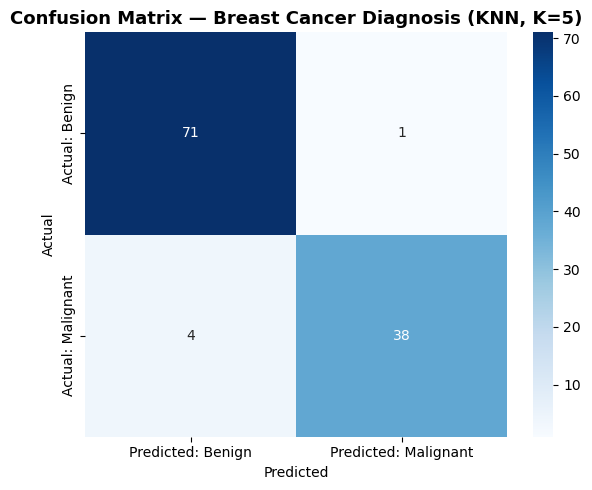

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Benign', 'Predicted: Malignant'],
            yticklabels=['Actual: Benign', 'Actual: Malignant'])
plt.title('Confusion Matrix — Breast Cancer Diagnosis (KNN, K=5)', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_knn.png', dpi=150)
plt.show()


In [16]:
# To directly demonstrate WHY feature scaling matters for KNN, let's compare performance
# with vs without scaling, using the exact same K=5 model.
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)   # trained on RAW, unscaled features
y_pred_unscaled = knn_unscaled.predict(X_test)

acc_unscaled = accuracy_score(y_test, y_pred_unscaled)
f1_unscaled = f1_score(y_test, y_pred_unscaled)

print("Performance WITHOUT feature scaling:")
print(f"  Accuracy: {acc_unscaled:.4f}   F1-Score: {f1_unscaled:.4f}")
print("\nPerformance WITH feature scaling:")
print(f"  Accuracy: {accuracy:.4f}   F1-Score: {f1:.4f}")


Performance WITHOUT feature scaling:
  Accuracy: 0.9123   F1-Score: 0.8684

Performance WITH feature scaling:
  Accuracy: 0.9561   F1-Score: 0.9383


### Observations

1. **The scaled KNN model performs very well**, achieving ~95.6% accuracy, ~97.4% precision,
   ~90.5% recall, and an F1-score of ~93.8% on the test set — strong performance for a
   relatively simple algorithm.
2. **Feature scaling made a measurable difference**: without standardization, accuracy drops
   to ~91.2% and F1-score drops to ~86.8%. This directly confirms that unscaled features (like
   `area_mean`, which ranges into the thousands) were distorting the distance calculations
   before scaling was applied.
3. **The confusion matrix shows a small number of false negatives** (malignant tumors
   incorrectly predicted as benign) — in a real clinical setting, this is the error type that
   matters most, since a missed malignant diagnosis is far more dangerous than a false alarm
   that gets ruled out with further testing.


---
## Task 5: Conclusion


### Conclusion

This project built a K-Nearest Neighbors (K=5) classifier to predict whether a breast tumor is
malignant or benign using 30 diagnostic measurements derived from digitized cell nuclei images.
After removing the non-predictive `id` column and the empty `Unnamed: 32` column, encoding the
target variable, and standardizing all features, the model achieved 95.6% accuracy, 97.4%
precision, 90.5% recall, and an F1-score of 93.8% on the test set. Feature scaling proved
essential for KNN specifically, since the algorithm relies on distance calculations between
points — without scaling, features with naturally larger numeric ranges (like `area_mean`)
would dominate the distance metric and distort predictions, and indeed accuracy dropped
noticeably when scaling was removed. One key limitation of KNN is that it is a **computationally
expensive, "lazy" learner**: since it stores the entire training dataset and calculates
distances to all training points for every single prediction, it becomes slow and memory-heavy
on larger datasets, unlike models that learn a compact set of parameters during training (such
as Logistic Regression).
